In [1]:
import numpy as np
from pyscf import gto, scf, cc

####  test H2 monomers ####
a = 2 # bond length in a cluster
d = 4 # distance between each cluster
unit = 'b' # unit of length
na = 2 # size of a cluster (monomer)
nc = 1 # set as integer multiple of monomers
spin = 0 # spin per monomer
frozen = 0 # frozen orbital per monomer
elmt = 'H'
unit = 'B'
basis = 'sto6g'
atoms = ""
for n in range(nc*na):
    shift = ((n - n % na) // na) * (d-a)
    atoms += f"{elmt} {n*a+shift:.5f} 0.00000 0.00000 \n"
###########################

mol = gto.M(atom=atoms,
            basis="sto6g",
            verbose=4,
            unit=unit,
            symmetry=0,
            charge=0,
            spin=spin*nc,
            max_memory=40000,
            )

mf = scf.RHF(mol)
mf.kernel()

mycc = cc.CCSD(mf).set_frozen()
mycc.kernel()

System: uname_result(system='Linux', node='sharmagroup-rn', release='6.17.0-29-generic', version='#29~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Mon May 11 10:30:58 UTC 2', machine='x86_64')  Threads 16
Python 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
numpy 2.4.4  scipy 1.17.1  h5py 3.16.0
Date: Tue Jun  2 18:25:37 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] OLD_PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:
[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:/home/sharmagroup/sharmagroup/pyscf-forge:
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 2
[INPUT] num. electrons = 2
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry 0 subgroup None
[INPUT] Mole.unit = B
[INPUT] Symbol           X                Y                Z      unit

(np.float64(-0.039641400884833235),
 array([[-5.66005116e-16]]),
 array([[[[-0.19736585]]]]))

In [ ]:
from jax import random
from jax import numpy as jnp
from afqmc import prep

def init_mf_prop_data(
    trial,
    wave_data: dict,
    ham_data: dict,
    options: dict,
    ) -> dict:

    print("\nInitalize QMC walkers by mean-field")
    prop_data = {}
    prop_data["n_killed_walkers"] = 0
    prop_data["key"] = random.PRNGKey(options["seed"])
    prop_data["weights"] = jnp.ones(options["n_walkers"])
    prop_data["walkers"] = jnp.array([wave_data["mo_coeff"]]*options["n_walkers"], dtype=jnp.complex128)
    energies = jnp.real(trial.calc_energy(prop_data["walkers"], ham_data, wave_data))
    guide_olps = trial.calc_overlap(prop_data["walkers"], wave_data)
    trial_olps = trial.calc_trial_overlap(prop_data["walkers"], wave_data)
    olp_ratio = trial_olps / guide_olps
    weights_p = prop_data["weights"] * olp_ratio
    e_estimate = (jnp.sum(weights_p * energies) / jnp.sum(weights_p)).real
    prop_data["e_estimate"] = e_estimate
    prop_data["pop_control_ene_shift"] = e_estimate
    prop_data["overlaps"] = guide_olps
    return prop_data

def init_ccsd_prop_data(trial,
                        wave_data, 
                        ham_data,
                        options,
                        ):
    
    print("\nInitalize QMC walkers by stochastic CCSD")
    prop_data = {}
    prop_data["n_killed_walkers"] = 0
    prop_data["key"] = random.PRNGKey(options["seed"])
    
    weights0 = jnp.ones(options["n_walkers"])
    walkers0 = jnp.array([wave_data["mo_coeff"]]*options["n_walkers"], dtype=jnp.complex128)
    overlaps0 = trial.calc_overlap(walkers0, wave_data)


    walkers1, prop_data = prep.get_ccsd_walkers(
        prop_data, wave_data, options["n_walkers"], options["walker_type"])
    overlaps1 = trial.calc_overlap(walkers1, wave_data)
    weights1 = jnp.real(weights0 * overlaps1 / overlaps0)

    prop_data["weights"] = weights1
    prop_data["walkers"] = walkers1
    prop_data["overlaps"] = overlaps1

    h0 = ham_data["h0"]
    t1s, t2s, e0s, e1s = trial.calc_energy_pt(prop_data["walkers"], ham_data, wave_data)

    wt = jnp.sum(weights1)
    t1 = jnp.sum(weights1 * t1s) / wt
    t2 = jnp.sum(weights1 * t2s) / wt
    e0 = jnp.sum(weights1 * e0s) / wt
    e1 = jnp.sum(weights1 * e1s) / wt

    energy = jnp.real(h0 + e0 / t1 + e1 / t1 - t2 * e0 / t1**2)

    prop_data["e_estimate"] = energy
    prop_data["pop_control_ene_shift"] = energy

    return prop_data

In [ ]:
import jax
jax.config.update("jax_enable_x64", True)

from jax import numpy as jnp
import opt_einsum as oe

import h5py
import numpy as np
from typing import Optional, Union

from pyscf import lib, scf
from pyscf.cc.ccsd import CCSD
from pyscf.cc.uccsd import UCCSD

from afqmc import cholesky, integral

from functools import partial
print = partial(print, flush=True)

def get_cc_amps(cc, save2disk, amp_file):

    if isinstance(cc, UCCSD):
        t1a = np.array(cc.t1[0])
        t1b = np.array(cc.t1[1])
        t2aa, t2ab, t2bb = cc.t2
        t2aa = (t2aa - t2aa.transpose(0, 1, 3, 2)) / 2
        t2bb = (t2bb - t2bb.transpose(0, 1, 3, 2)) / 2
        t2aa = t2aa.transpose(0, 2, 1, 3)
        t2bb = t2bb.transpose(0, 2, 1, 3)
        t2ab = t2ab.transpose(0, 2, 1, 3)
        if save2disk:
            np.savez(
                amp_file,
                t1a=t1a,
                t1b=t1b,
                t2aa=t2aa,
                t2ab=t2ab,
                t2bb=t2bb,
            )
        t1 = [t1a, t1b]
        t2 = [t2aa, t2ab, t2bb]

    elif isinstance(cc, CCSD):
        t1 = np.array(cc.t1)
        t2 = cc.t2
        t2 = t2.transpose(0, 2, 1, 3)
        if save2disk:
            np.savez(amp_file, t1=t1, t2=t2)

    return t1, t2


def read_cc_amps(amp_file):
    data = np.load(amp_file)

    if "t1a" in data:  # UCCSD
        t1 = [data["t1a"], data["t1b"]]
        t2 = [data["t2aa"], data["t2ab"], data["t2bb"]]
    else:              # CCSD
        t1 = data["t1"]
        t2 = data["t2"]

    return t1, t2

def write_integral(nelec, norb, h0, h1, chol, filename):
    with h5py.File(filename, "w") as fh5:
        fh5["nelec"] = nelec
        fh5["norb"] = norb
        fh5["h0"] = h0

        if isinstance(h1, (tuple, list)):
            fh5["h1a"] = h1[0]
            fh5["h1b"] = h1[1]
        else:
            fh5["h1"] = h1

        if isinstance(chol, (tuple, list)):
            fh5["chola"] = chol[0]
            fh5["cholb"] = chol[1]
        else:
            fh5["chol"] = chol

def read_integral(filename):
    with h5py.File(filename, "r") as fh5:
        nelec_arr = fh5["nelec"][()]
        nelec = tuple(int(x) for x in nelec_arr)

        norb_arr = fh5["norb"][()]
        norb = int(norb_arr) if norb_arr.ndim == 0 else tuple(int(x) for x in norb_arr)

        h0 = float(fh5["h0"][()])

        if "h1a" in fh5:
            h1 = (jnp.asarray(fh5["h1a"][()]), jnp.asarray(fh5["h1b"][()]))
        else:
            h1 = jnp.asarray(fh5["h1"][()])

        if "chola" in fh5:
            chol = (jnp.asarray(fh5["chola"][()]), jnp.asarray(fh5["cholb"][()]))
        else:
            chol = jnp.asarray(fh5["chol"][()])

    return nelec, norb, h0, h1, chol


def get_hamiltonian(mf, 
                    norb_frozen=0, 
                    chol_cut=1e-5, 
                    basis_coeff=None, 
                    save2disk=False,
                    ham_file="FCIDUMP_chol"
                    ):

    mol = mf.mol
    nao = mf.mol.nao

    if basis_coeff is None:
        basis_coeff = mf.mo_coeff
    
    if getattr(mf, "with_df", None) is not None:
        print('Find Density Fit Teonsers in Mean-Field object')
        print('Hamltonian will be construncted with Density Fit')
        useDF = True
    else:
        useDF = False

    if isinstance(mf, scf.rhf.RHF):
        spin_type = "restricted"
        nbasis = nao - norb_frozen
        nocc = int(np.count_nonzero(mf.mo_occ))
        nelec = [nocc - norb_frozen, nocc - norb_frozen]
        h1e, h0 = integral.h1e_ras(mf, basis_coeff, nbasis, norb_frozen, useDF)
        chol_ao = cholesky.cholesky_by_mol(mol, max_error=chol_cut, cmax=10)
        chol_ao = jnp.array(chol_ao.reshape((-1, nao, nao)))
        chol = cholesky.cderi2mo_gpu(chol_ao, basis_coeff)
        chol = cholesky.unpack_symmetric(chol, nao)
        chol = chol[:, norb_frozen:, norb_frozen:]

        # v0 = 0.5 * oe.contract("gpr,gqr->pq", chol, chol, backend="jax")
        # h1e_mod = h1e - v0
        # chol = chol.reshape((chol.shape[0], -1))
            
    elif isinstance(mf, scf.uhf.UHF):
        spin_type = "unrestricted"
        ncore = np.array([norb_frozen, norb_frozen], dtype = np.int32)
        nocc = np.array([np.count_nonzero(mf.mo_occ[0]),
                         np.count_nonzero(mf.mo_occ[1])],
                         dtype = np.int32)
        nelec = nocc - norb_frozen
        ncas = nao - ncore
        nbasis = ncas[0]
        h1e, h0 = integral.h1e_uas(mf, basis_coeff, ncas, ncore, useDF)

        chol_ao = cholesky.cholesky_by_mol(mol, max_error=chol_cut, cmax=10)
        chol_ao = jnp.array(chol_ao.reshape((-1, nao, nao)))
        chol_a = cholesky.cderi2mo_gpu(chol_ao, basis_coeff[0])
        chol_b = cholesky.cderi2mo_gpu(chol_ao, basis_coeff[1])
        chol_a = cholesky.unpack_symmetric(chol_a, nao)
        chol_b = cholesky.unpack_symmetric(chol_b, nao)
        chol_a = chol_a[:, ncore[0]:, ncore[0]:]
        chol_b = chol_b[:, ncore[1]:, ncore[1]:]
        # v0_a = 0.5 * oe.contract("gpr,gqr->pq", chol_a, chol_a, backend="jax")
        # v0_b = 0.5 * oe.contract("gpr,gqr->pq", chol_b, chol_b, backend="jax")
        # h1e = jnp.array(h1e)
        # h1e_mod = jnp.array(h1e - jnp.array([v0_a,v0_b]))
        # chol = jnp.array([chol_a.reshape(chol_a.shape[0], -1), chol_b.reshape(chol_b.shape[0], -1)])
        chol = (chol_a, chol_b)
    
    if save2disk:
        write_integral(nelec, nbasis, h0, h1e, chol, ham_file)

    return nelec, nbasis, h0, h1e, chol


def prep_system(
    mf_cc: Union[scf.rhf.RHF, scf.uhf.UHF, CCSD, UCCSD],
    basis_coeff: Optional[np.ndarray] = None,
    nfrozen: int = 0,
    chol_cut: float = 1e-5,
    save2disk = True,
    amp_file = "amplitudes.npz",
    ham_file = "FCIDUMP_chol"
):

    print("\nPreparing AFQMC system")

    if isinstance(mf_cc, (CCSD, UCCSD)):
        mf = mf_cc._scf
        cc = mf_cc
        t1, t2 = get_cc_amps(cc, save2disk, amp_file)
        if cc.frozen is not None:
            nfrozen = cc.frozen
    else:
        mf = mf_cc
        t1, t2 =  None, None

    if basis_coeff is None:
        basis_coeff = mf.mo_coeff

    nelec, norb, h0, h1, chol = get_hamiltonian(mf, nfrozen, chol_cut, basis_coeff, save2disk, ham_file)

    myqmc = QMCSystem(nelec, norb, h0, h1, chol, t1, t2)

    print("Finished preparing AFQMC object")
    print(f"Number of electrons:        {myqmc.nelec}")
    print(f"Number of basis functions:  {myqmc.norb}")
    print(f"Number of Cholesky vectors: {myqmc.nchol}")

    if save2disk: 
        return None
    else:
        return myqmc

In [2]:
from afqmc import integral
integral.prep_integral(mycc, chol_cut=1e-5)


Preparing AFQMC calculation
Calculating Cholesky integrals
Finished calculating Cholesky integrals
Size of the correlation space:
Number of electrons:        [1, 1]
Number of basis functions:  2
Number of Cholesky vectors: 3


In [3]:
import h5py
from jax import numpy as jnp
from afqmc import cholesky, propagation
from afqmc.wavefunctions import rwfn_exp

def load_afqmc(options=None,
               amp_file="amplitudes.npz",
               chol_file="FCIDUMP_chol"):

    options["dt"] = options.get("dt", 0.005)
    options["eql_time"] = options.get("eql_time", 20)
    options["n_walkers"] = options.get("n_walkers", 50)
    options["n_prop_steps"] = options.get("n_prop_steps", 50)
    options["n_blocks"] = options.get("n_blocks", 500)
    options["seed"] = options.get("seed", np.random.randint(1, int(1e6)))
    options["n_exp_terms"] = options.get("n_exp_terms",6)
    options["walker_type"] = options.get("walker_type", "rhf")
    options["trial"] = options.get("trial", None)
    options["free_projection"] = options.get("free_projection", False)
    options["n_batch"] = options.get("n_batch", 1)
    options["max_error"] = options.get("max_error", 0.0)
    options["nchol_chunk"] = options.get("nchol_chunk", 100)
    options["max_memory"] = options.get("max_memory", 2000) # MB
    options["mix_precision"] = options.get("mix_precision", True)

    print("\nLoad system from Integral File")

    with h5py.File(chol_file, "r") as fh5:
        [nelec, norb, ms] = fh5["header"]
        spin_type = fh5["spin_type"][()]
        h0 = jnp.array(fh5.get("energy_core"))
        h1 = jnp.array(fh5.get("hcore"))
        chol = jnp.array(fh5.get("chol"))
        h1_mod = jnp.array(fh5.get("hcore_mod"))
    
    if isinstance(spin_type, bytes):
        spin_type = spin_type.decode()

    assert spin_type in ["restricted", "unrestricted"]

    if spin_type == 'restricted':
        h1 = jnp.array(h1).reshape(norb, norb)
        h1_mod = jnp.array(h1_mod).reshape(norb, norb)
        chol = jnp.array(chol).reshape(-1, norb, norb)

    elif spin_type == 'unrestricted':
        h1 = jnp.array(h1).reshape(2, norb, norb)
        h1_mod = jnp.array(h1_mod).reshape(2, norb, norb)
        chol = jnp.array(chol).reshape(2, -1, norb, norb)

    assert type(ms) is np.int64
    assert type(nelec) is np.int64
    assert type(norb) is np.int64

    ms, nelec, norb = int(ms), int(nelec), int(norb)
    nelec_sp = ((nelec + abs(ms)) // 2, (nelec - abs(ms)) // 2)

    ham_data = {}
    ham_data["h0"] = h0

    if spin_type == 'restricted':
        ham_data["h1"] = jnp.array([h1, h1])
        ham_data["h1_mod"] = jnp.array(h1_mod)
        nchol = chol.shape[0]
        ham_data["chol"] = jnp.array(chol.reshape(chol.shape[0], -1))
    elif spin_type == 'unrestricted':
        ham_data["h1"] = jnp.array(h1)
        ham_data["h1_mod"] = jnp.array(h1_mod)
        nchol = chol[0].shape[0]
        ham_data["chol"] = jnp.array([chol[0].reshape(chol[0].shape[0], -1),
                                      chol[1].reshape(chol[1].shape[0], -1)])
        # ham_data["chol"] = [jnp.array(chol[0]), jnp.array(chol[1])]

    options["nchol_chunk"] = cholesky.chunk_chol(
        chol, options["nchol_chunk"], options["max_memory"]/options["n_walkers"])

    wave_data = {}
    mo_coeff = jnp.array([np.eye(norb),np.eye(norb)])

    if spin_type == "restricted":
        nocc = nelec_sp[0]
        wave_data["mo_coeff"] = mo_coeff[0][:,:nocc]
        wave_data["nelec"] = nelec_sp
        wave_data["norb"] = norb
        wave_data["nchol"] = nchol
        wave_data["rdm1"] = jnp.array([wave_data["mo_coeff"] @ wave_data["mo_coeff"].T] * 2)
        amplitudes = np.load(amp_file)
        t1 = jnp.array(amplitudes["t1"])
        t2 = jnp.array(amplitudes["t2"])
        ci2 = t2 + jnp.einsum("ia,jb->iajb", t1, t1)
        wave_data["ci1"] = t1
        wave_data["ci2"] = ci2
        
    print("\nQMC System")
    print(f"Number of electrons: {nelec_sp}")
    print(f"Spin Multiplicity:   {ms}")
    print(f"Number of orbitals:  {norb}")
    print(f"Number of Chol:      {nchol}")

    print("\nQMC Parameters")
    for op in options:
        if options[op] is not None:
            print(f"{str(op):<20s}: {str(options[op]):>20s}")

    return ham_data, wave_data, options

In [4]:
options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'walker_type': 'rhf',
            'trial': 'pt2ccsd',
            }

ham_data, wave_data, options = load_afqmc(options)


Load system from Integral File
Maximum memory per walker:            6.67 MB
Maximum number of Cholesky per chunk: 109226
Number of Cholesky chunks:            1
Number of Cholesky per chunk:         3
Number of padding Cholesky:           0

QMC System
Number of electrons: (1, 1)
Spin Multiplicity:   0
Number of orbitals:  2
Number of Chol:      3

QMC Parameters
eql_time            :                   10
n_blocks            :                  100
n_walkers           :                  300
max_error           :                  0.0
mix_precision       :                False
seed                :                   17
walker_type         :                  rhf
trial               :              pt2ccsd
dt                  :                0.005
n_prop_steps        :                   50
n_exp_terms         :                    6
free_projection     :                False
n_batch             :                    1
nchol_chunk         :                    3
max_memory          :         

In [5]:
from jax import random

def init_prop_data(
    trial,
    wave_data: dict,
    ham_data: dict,
    options: dict,
) -> dict:
    prop_data = {}
    prop_data["n_killed_walkers"] = 0
    prop_data["key"] = random.PRNGKey(options["seed"])
    prop_data["weights"] = jnp.ones(options["n_walkers"])
    prop_data["walkers"] = jnp.array([wave_data["mo_coeff"]]*options["n_walkers"], dtype=jnp.complex128)
    energies = jnp.real(trial.calc_energy(prop_data["walkers"], ham_data, wave_data))
    guide_olps = trial.calc_overlap(prop_data["walkers"], wave_data)
    trial_olps = trial.calc_trial_overlap(prop_data["walkers"], wave_data)
    olp_ratio = trial_olps / guide_olps
    weights_p = prop_data["weights"] * olp_ratio
    e_estimate = (jnp.sum(weights_p * energies) / jnp.sum(weights_p)).real
    prop_data["e_estimate"] = e_estimate
    prop_data["pop_control_ene_shift"] = e_estimate
    prop_data["overlaps"] = guide_olps
    return prop_data

In [6]:
from afqmc.sampling import sampler_exp
from afqmc.wavefunctions import rhf_wfn, rcisd_wfn

prop = propagation.propagator_restricted(
        options["dt"], 
        options["n_walkers"], 
        options["n_exp_terms"],
        options["n_batch"]
    )

pure_rhf = rwfn_exp.rwfn(    
    guide_overlap_fn=rhf_wfn.r_overlap,
    trial_overlap_fn=rhf_wfn.r_overlap,
    force_bias_fn=rhf_wfn.r_force_bias,
    energy_fn=rhf_wfn.r_energy,
    nelec=wave_data["nelec"],
    norb=wave_data["norb"],
    nchol=wave_data["nchol"],
    nchol_chunk=options["nchol_chunk"],
    )

sampler = sampler_exp(
    options["n_prop_steps"],
    options["n_blocks"],
    n_chol=wave_data["nchol"],
    )

In [7]:
import time
import numpy as np
from afqmc import config
from functools import partial

print = partial(print, flush=True)
init_time = time.time()

# prep.print_start()
config.setup_jax()

ham_data = prop._build_propagation_intermediates(ham_data, pure_rhf, wave_data)
prop_data = init_prop_data(pure_rhf, wave_data, ham_data, options)

init_e = prop_data["e_estimate"]
init_w = np.sum(prop_data["weights"])

print("\nEquilibration")

print(f"{'inv_T':>5s}  "
      f"{'weight':>12s}  {'killW':>5s}  "
      f"{'weightp':>12s}  {'energy':>12s}  {'runTime':>8s}")

print(f"{0.:5.2f}  "
      f"{init_w:12.6f}  {0:5d}  "
      f"{init_w:12.6f}  {init_e:12.6f}  {time.time() - init_time:8.2f}")


block_time = prop.dt * sampler.n_prop_steps
neql_block = int(-(-options["eql_time"] // block_time))
# neql_block = 100

weightsp = np.zeros(neql_block, dtype=np.complex128)
energies = np.zeros(neql_block, dtype=np.complex128)

for n in range(1, neql_block+1):
    prop_data, (wt, wp, e) \
        = sampler.block_sample(prop, pure_rhf, prop_data, ham_data, wave_data)
    
    weightsp[n-1] = wp
    energies[n-1] = e

    if (n+1) % (min(max(neql_block // 10, 1), 20)) == 0 and n > 0:
        nkill = prop_data["n_killed_walkers"]
        print(f"{(n+1)*block_time:5.2f}  "
              f"{wt.real:12.6f}  {nkill:5d}  "
              f"{wp.real:12.6f}  {e.real:12.6f}  "
              f"{time.time() - init_time:8.2f}")

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      6.17.0-29-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

Equilibration
inv_T        weight  killW       weightp        energy   runTime
 0.00    300.000000      0    300.000000     -1.056430      1.35
 1.00    300.320862      0    300.320862     -1.075570      3.58
 2.00    300.573496      0    300.573496     -1.097327      3.62
 3.00    300.539869      0    300.539869     -1.096249      3.65
 4.00    300.476808      0    300.476808     -1.088795      3.69
 5.00    300.548964      0    300.548964     -1.092692      3.73
 6.00    300.504732      0    300.504732     -1.084771      3.76
 7.00    300.437130      0    300.437130     -1.084311      3.80
 8.00    300.517955      0    300.517955     -1.084974      3.84
 9.00    300.553783      0    300.553783     -1.095438      3.87
10.00   

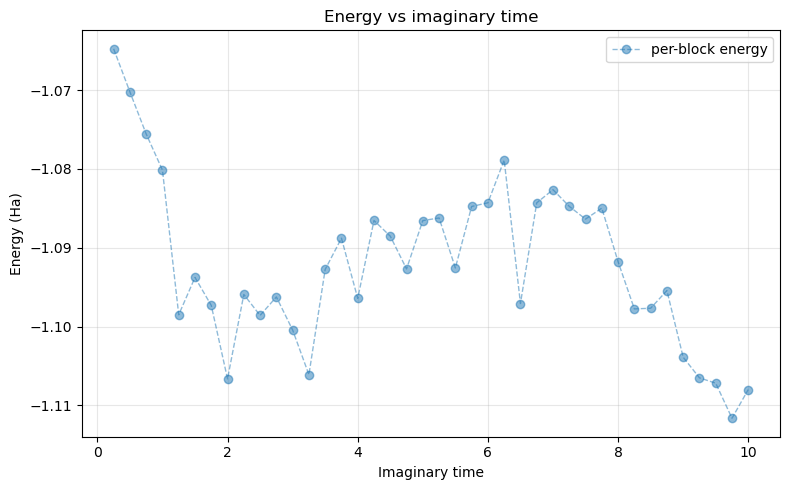

In [10]:
import matplotlib.pyplot as plt

imag_time = np.arange(1, neql_block + 1) * block_time

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, energies.real, "o--", lw=1, alpha=0.5, label="per-block energy")

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("Energy vs imaginary time")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
walkers = prop_data["walkers"]
print(walkers.shape)

(300, 2, 1)


In [13]:
from jax import lax

def calc_walkers_norm(walkers):

    def scan_walkers(carry, walker):
        norm = rhf_wfn.r_slater_overlap(walker,walker)
        return carry, norm

    init_carry = 0.0
    _, norms = lax.scan(scan_walkers, init_carry, walkers)

    return norms

In [14]:
norms = calc_walkers_norm(walkers)
print(norms)

[1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j
 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j
 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j
 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j
 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j
 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j
 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j
 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j
 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j
 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j
 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j
 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j
 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j
 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j
 1.+0.

In [7]:
import time
import numpy as np
from afqmc import config
from functools import partial

print = partial(print, flush=True)
init_time = time.time()

# prep.print_start()
config.setup_jax()

ham_data = prop._build_propagation_intermediates(ham_data, pure_rhf, wave_data)
prop_data = init_prop_data(pure_rhf, wave_data, ham_data, options)

init_e = prop_data["e_estimate"]
init_w = np.sum(prop_data["weights"])

print("\nEquilibration")

print(f"{'inv_T':>5s}  "
      f"{'weight':>12s}  {'killW':>5s}  "
      f"{'weightp':>12s}  {'energy':>12s}  {'runTime':>8s}")

print(f"{0.:5.2f}  "
      f"{init_w:12.6f}  {0:5d}  "
      f"{init_w:12.6f}  {init_e:12.6f}  {time.time() - init_time:8.2f}")


block_time = prop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
neql_block = 1000

weightsp = np.zeros(neql_block, dtype=np.complex128)
energies = np.zeros(neql_block, dtype=np.complex128)

for n in range(1, neql_block+1):
    prop_data, (wt, wp, e) \
        = sampler.block_sample(prop, pure_rhf, prop_data, ham_data, wave_data)
    
    weightsp[n-1] = wp
    energies[n-1] = e

    if (n+1) % (min(max(neql_block // 10, 1), 20)) == 0 and n > 0:
        nkill = prop_data["n_killed_walkers"]
        print(f"{(n+1)*block_time:5.2f}  "
              f"{wt.real:12.6f}  {nkill:5d}  "
              f"{wp.real:12.6f}  {e.real:12.6f}  "
              f"{time.time() - init_time:8.2f}")

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      6.17.0-29-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

Equilibration
inv_T        weight  killW       weightp        energy   runTime
 0.00    300.000000      0    300.000000     -1.056430      1.36
 5.00    300.548964      0    300.548964     -1.092692      3.69
10.00    300.623201      0    300.623201     -1.111641      3.87
15.00    300.427687      0    300.427687     -1.087516      4.05
20.00    300.538077      0    300.538077     -1.095305      4.23
25.00    300.446543      0    300.446543     -1.088213      4.41
30.00    300.454100      0    300.454100     -1.093637      4.59
35.00    300.650029      0    300.650029     -1.099966      4.77
40.00    300.462057      0    300.462057     -1.091092      4.95
45.00    300.525236      0    300.525236     -1.094765      5.13
50.00   

E = -1.093359 +/- 0.000231 Ha  (averaged over 921 blocks, t >= 20)


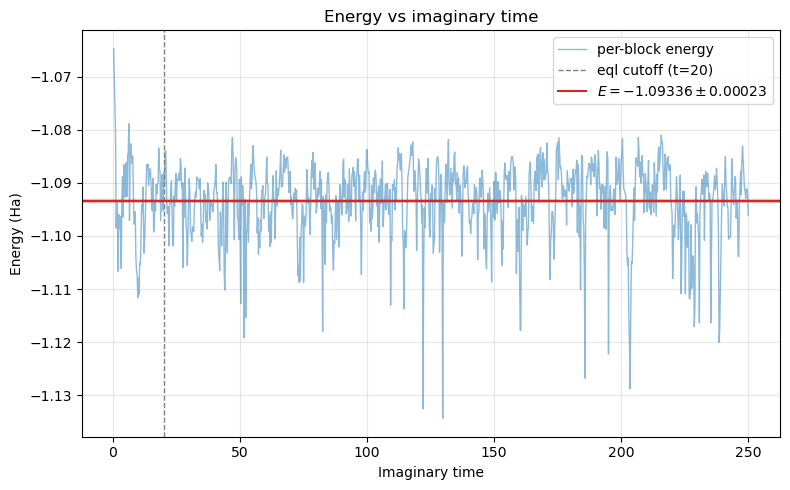

In [8]:
import matplotlib.pyplot as plt

imag_time = np.arange(1, neql_block + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w = weightsp[mask].real
e = energies[mask].real
N = len(e)

# weight-averaged energy
E_mean = np.sum(w * e) / np.sum(w)

# weighted variance (Bessel-corrected) -> std of the mean
wvar = np.sum(w * (e - E_mean) ** 2) / np.sum(w) * N / (N - 1)
sem = np.sqrt(wvar / N)

print(f"E = {E_mean:.6f} +/- {sem:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, energies.real, lw=1, alpha=0.5, label="per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean, color="C3", lw=1.5,
            label=fr"$E = {E_mean:.5f} \pm {sem:.5f}$")
plt.axhspan(E_mean - sem, E_mean + sem, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("Energy vs imaginary time")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
rhf_guide_cisd = rwfn_exp.rwfn(    
    guide_overlap_fn=rcisd_wfn.r_overlap,
    trial_overlap_fn=rhf_wfn.r_overlap,
    force_bias_fn=rcisd_wfn.r_force_bias,
    energy_fn=rhf_wfn.r_energy,
    nelec=wave_data["nelec"],
    norb=wave_data["norb"],
    nchol=wave_data["nchol"],
    nchol_chunk=options["nchol_chunk"],
    )

In [10]:
import time
import numpy as np
from afqmc import config
from functools import partial

print = partial(print, flush=True)
init_time = time.time()

# prep.print_start()
config.setup_jax()

ham_data = prop._build_propagation_intermediates(ham_data, rhf_guide_cisd, wave_data)
prop_data = init_prop_data(rhf_guide_cisd, wave_data, ham_data, options)

init_e = prop_data["e_estimate"]
init_w = np.sum(prop_data["weights"])

print("\nEquilibration")

print(f"{'inv_T':>5s}  "
      f"{'weight':>12s}  {'killW':>5s}  "
      f"{'weightp':>12s}  {'energy':>12s}  {'runTime':>8s}")

print(f"{0.:5.2f}  "
      f"{init_w:12.6f}  {0:5d}  "
      f"{init_w:12.6f}  {init_e:12.6f}  {time.time() - init_time:8.2f}")


block_time = prop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
neql_block = 1000

weightsp2 = np.zeros(neql_block, dtype=np.complex128)
energies2 = np.zeros(neql_block, dtype=np.complex128)

for n in range(1, neql_block+1):
    prop_data, (wt, wp, e) \
        = sampler.block_sample(prop, rhf_guide_cisd, prop_data, ham_data, wave_data)
    
    weightsp2[n-1] = wp
    energies2[n-1] = e

    if (n+1) % (min(max(neql_block // 10, 1), 20)) == 0 and n > 0:
        nkill = prop_data["n_killed_walkers"]
        print(f"{(n+1)*block_time:5.2f}  "
              f"{wt.real:12.6f}  {nkill:5d}  "
              f"{wp.real:12.6f}  {e.real:12.6f}  "
              f"{time.time() - init_time:8.2f}")

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      6.17.0-29-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

Equilibration
inv_T        weight  killW       weightp        energy   runTime
 0.00    300.000000      0    300.000000     -1.056430      0.54
 5.00    300.609422      0    291.085776     -1.089192      3.21
10.00    300.475967      0    286.107178     -1.106445      3.45
15.00    300.553220      0    290.337214     -1.090839      3.70
20.00    300.569405      0    289.079221     -1.095492      3.94
25.00    300.567180      0    291.348605     -1.088329      4.19
30.00    300.494677      0    289.822873     -1.093513      4.44
35.00    300.693233      0    288.647047     -1.094035      4.69
40.00    300.499442      0    289.416006     -1.089395      4.93
45.00    300.568944      0    288.623209     -1.092207      5.18
50.00   

E = -1.092914 +/- 0.000120 Ha  (averaged over 921 blocks, t >= 20)


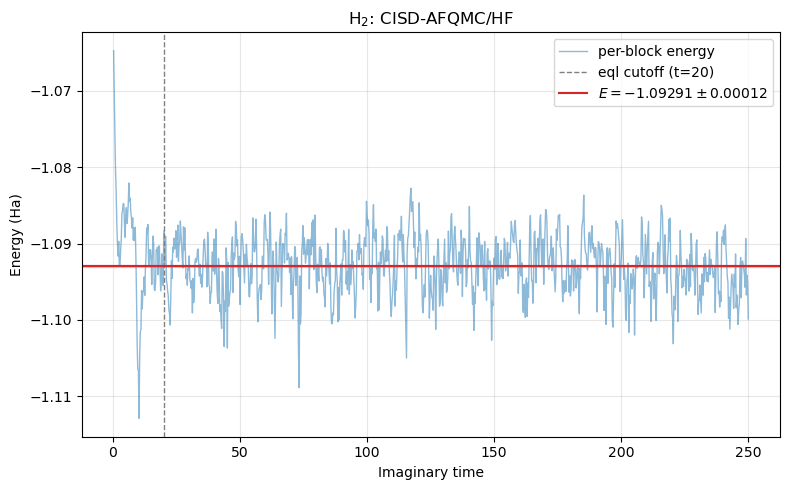

In [11]:
import matplotlib.pyplot as plt

imag_time = np.arange(1, neql_block + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w2 = weightsp2[mask].real
e2 = energies2[mask].real
N = len(e2)

# weight-averaged energy
E_mean2 = np.sum(w2 * e2) / np.sum(w2)

# weighted variance (Bessel-corrected) -> std of the mean
wvar2 = np.sum(w2 * (e2 - E_mean2) ** 2) / np.sum(w2) * N / (N - 1)
sem2 = np.sqrt(wvar2 / N)

print(f"E = {E_mean2:.6f} +/- {sem2:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, energies2.real, lw=1, alpha=0.5, label="per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean2, color="C3", lw=1.5,
            label=fr"$E = {E_mean2:.5f} \pm {sem2:.5f}$")
plt.axhspan(E_mean2 - sem2, E_mean2 + sem2, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("H$_2$: CISD-AFQMC/HF")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

E = -1.093359 +/- 0.000231 Ha  (averaged over 921 blocks, t >= 20)


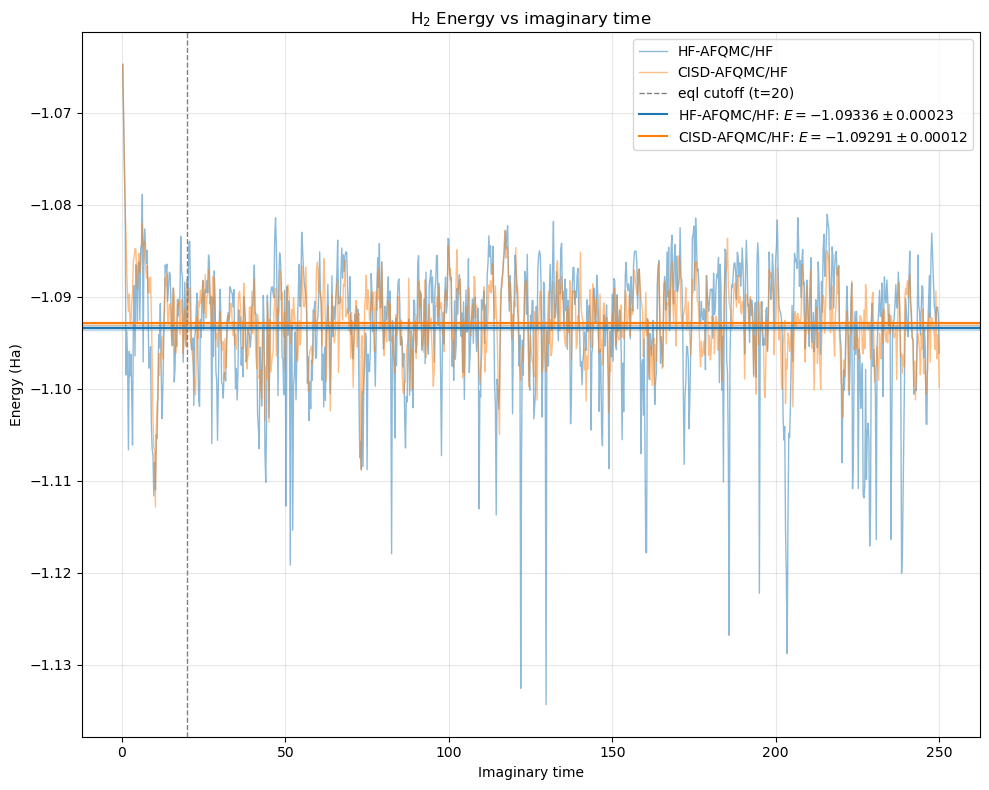

In [13]:
imag_time = np.arange(1, neql_block + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w = weightsp[mask].real
e = energies[mask].real
N = len(e)

# weight-averaged energy
E_mean = np.sum(w * e) / np.sum(w)

# weighted variance (Bessel-corrected) -> std of the mean
wvar = np.sum(w * (e - E_mean) ** 2) / np.sum(w) * N / (N - 1)
sem = np.sqrt(wvar / N)

print(f"E = {E_mean:.6f} +/- {sem:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(10, 8))
plt.plot(imag_time, energies.real, lw=1, color="C0", alpha=0.5, label="HF-AFQMC/HF")
plt.plot(imag_time, energies2.real, lw=1, color="C1", alpha=0.5, label="CISD-AFQMC/HF")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean, lw=1.5, color="C0", label=fr"HF-AFQMC/HF: $E = {E_mean:.5f} \pm {sem:.5f}$")
plt.axhspan(E_mean - sem, E_mean + sem, color="C0", alpha=0.2)
plt.axhline(E_mean2, lw=1.5, color="C1", label=fr"CISD-AFQMC/HF: $E = {E_mean2:.5f} \pm {sem2:.5f}$")
plt.axhspan(E_mean2 - sem2, E_mean2 + sem2, color="C1",alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("H$_2$ Energy vs imaginary time")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()